# CSCI/MATH 485 Assignment
## Customer Churn Prediction with XGBoost


This notebook is compatible with **Jupyter Notebook** and **Google Colab**.

 


## 1. Setup


In [ ]:
# If you are using Google Colab, uncomment the next line if xgboost is not installed.
# !pip install xgboost


In [3]:
import sys
print(sys.executable)

c:\Program Files\Python313\python.exe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load the Dataset

**Instructions for students**
- Load the IBM Telco Customer Churn dataset.
- Display the first few rows.
- Confirm the dataset shape.
- If the url doesn't work for you, download the csv file from the Canvas Assignment#4

In [3]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/telco-customer-churn-by-IBM.csv"
df = pd.read_csv(url)

# Display the first 5 rows of the dataset (done below)
df.head()

# TODO:
# Display the shape of the dataset
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset shape: 7043 rows x 21 columns


## 3. Data Exploration

Complete the following:
- Print all column names
- Show data types
- Count missing values in each column
- Show the distribution of the target variable
- Write a short note: Is this a classification or regression problem? Why is this useful in business?


In [4]:
# TODO:
# Print column names
# Print data types
# Print missing values for each column
# Print value counts for the target column

print("Columns:")
print(list(df.columns))

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values detected (NaN-level).")

print("\nTarget distribution (Churn):")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")




Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values per column:
No missing values detect

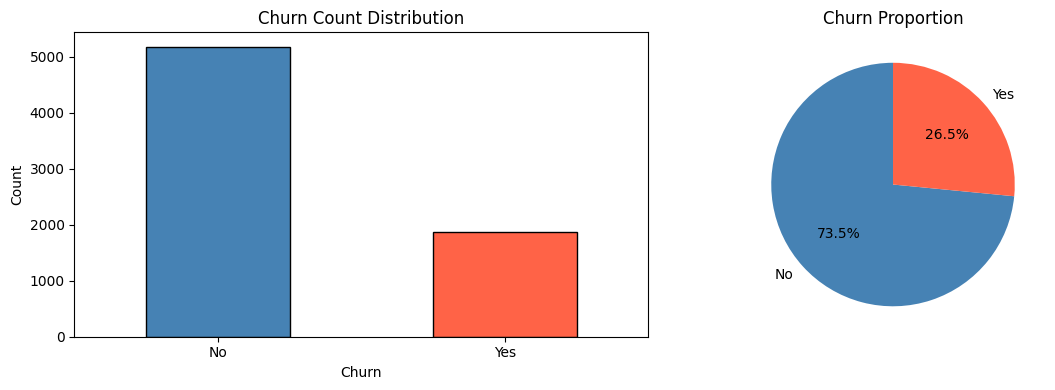


Descriptive Statistics (numeric columns):


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Visualize the target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Churn Count Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                  colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Churn Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Extra: Basic stats on numeric columns
print("\nDescriptive Statistics (numeric columns):")
display(df.describe())

### Part 1 Analysis

**1. What kind of machine learning problem is this?**

This is a **binary classification** problem. The goal is to predict whether a customer will churn (`Yes`) or not churn (`No`). The target variable `Churn` takes on exactly two values, making it a supervised classification task. We have labeled historical data and must learn a decision boundary that generalizes to new, unseen customers.

**2. Why is churn prediction important in a business setting?**

Customer churn is a critical business metric for subscription-based companies like telecom providers. Acquiring a new customer typically costs 5–25× more than retaining an existing one. By predicting which customers are at high risk of churning **before** they cancel, the company can proactively intervene with targeted offers, loyalty programs, or personalized outreach. Even a small reduction in churn rate translates to significant revenue gains. This makes churn prediction one of the highest-ROI applications of machine learning in business.

**Key dataset facts:**
- **7,043 rows** and **21 columns**
- Target variable: `Churn` (Yes/No)
- Churn rate ≈ **26.5%** — the dataset is imbalanced (roughly 3:1 ratio of non-churners to churners), which will influence our choice of evaluation metric.


## 4. Basic Cleaning

Complet the following:
- Identify whether there is an ID column that should be removed
- Convert the target column into binary form if needed
- Convert any numeric-looking columns stored as text into numeric values


In [6]:
# Make a copy so the original data remains unchanged
df_clean = df.copy()

# 1. Drop the customerID column — it is a unique identifier with no predictive value.
#    Including it would cause data leakage and add noise.
df_clean = df_clean.drop(columns=['customerID'])

# 2. Convert the target column to 0/1
#    Binary encoding is required for sklearn and XGBoost classifiers.
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# 3. Convert TotalCharges to numeric.
#    It is stored as object dtype because some entries contain whitespace (' ')
#    for new customers with 0 tenure. We coerce these to NaN and will impute.
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

print(f"TotalCharges NaNs introduced: {df_clean['TotalCharges'].isnull().sum()}")
print(f"Churn value counts: {df_clean['Churn'].value_counts().to_dict()}")
print(f"\nDataset shape after cleaning: {df_clean.shape}")
display(df_clean.head())


TotalCharges NaNs introduced: 11
Churn value counts: {0: 5174, 1: 1869}

Dataset shape after cleaning: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 5. Define Features and Target

Complet the following:
- Define `X` and `y`
- Set the correct target column


In [7]:
# TODO:
# Replace with the correct target column name
# The target column is 'Churn'
target_col = 'Churn'

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print(f"\nClass balance: {y.value_counts().to_dict()}")

Feature matrix shape: (7043, 19)
Target shape: (7043,)

Class balance: {0: 5174, 1: 1869}


## 6. Identify Numeric and Categorical Features

Complet the following:
- Create a list of numeric columns
- Create a list of categorical columns


In [8]:
# TODO:
# Identify numeric and categorical feature columns

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 7. Train/Test Split

Complet the following:
- Split the dataset into training and testing sets
- Use stratification if appropriate


In [9]:
# TODO:
# Create train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print(f"\nTrain churn rate: {y_train.mean():.4f}")
print(f"Test churn rate:  {y_test.mean():.4f}")

X_train shape: (5634, 19)
X_test shape: (1409, 19)

Train churn rate: 0.2654
Test churn rate:  0.2654


## 8. Preprocessing Pipelines

Build preprocessing for:
- numeric features
- categorical features

Then combine them into a `ColumnTransformer`.


In [10]:
# TODO:
# Build numeric preprocessing pipeline
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline:
#   - SimpleImputer with 'most_frequent': fills any unexpected NaNs
#   - OneHotEncoder with handle_unknown='ignore': safely ignores any unseen
#     categories in the test set, avoiding errors at predict time.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both preprocessing pipelines using ColumnTransformer.
# remainder='drop' ensures any unlisted columns are excluded.
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessor configured:")
print(preprocessor)


Preprocessor configured:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
          

## 9. Baseline Model: Logistic Regression

Complet the following:
- Train a Logistic Regression model as the baseline
- Generate predictions
- Evaluate using multiple metrics
- You may need to adjust `max_iter` if the model is not converging.


In [11]:
# Logistic Regression is a strong, interpretable baseline for binary classification.
# max_iter=1000 ensures convergence given the number of features after OHE.
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the baseline model on training data
baseline_model.fit(X_train, y_train)

# Generate predicted labels and probabilities
baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression model trained.")

Baseline Logistic Regression model trained.


In [12]:
# Compute and print all evaluation metrics
baseline_acc  = accuracy_score(y_test, baseline_preds)
baseline_prec = precision_score(y_test, baseline_preds)
baseline_rec  = recall_score(y_test, baseline_preds)
baseline_f1   = f1_score(y_test, baseline_preds)
baseline_roc  = roc_auc_score(y_test, baseline_probs)

print("=" * 45)
print("  Baseline: Logistic Regression Results")
print("=" * 45)
print(f"  Accuracy  : {baseline_acc:.4f}")
print(f"  Precision : {baseline_prec:.4f}")
print(f"  Recall    : {baseline_rec:.4f}")
print(f"  F1-Score  : {baseline_f1:.4f}")
print(f"  ROC-AUC   : {baseline_roc:.4f}")
print("=" * 45)


  Baseline: Logistic Regression Results
  Accuracy  : 0.8055
  Precision : 0.6572
  Recall    : 0.5588
  F1-Score  : 0.6040
  ROC-AUC   : 0.8419


Classification Report — Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



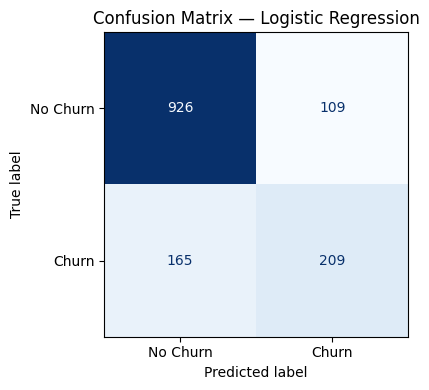

In [13]:
# Classification report and confusion matrix
print("Classification Report — Logistic Regression:")
print(classification_report(y_test, baseline_preds, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('cm_logistic.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Choose Your Main Evaluation Metric

**Chosen metric: ROC-AUC (Area Under the Receiver Operating Characteristic Curve)**

**Why ROC-AUC is appropriate for churn prediction:**

1. **Handles class imbalance:** The dataset has approximately 26.5% churners and 73.5% non-churners. A naive model that always predicts "No Churn" would achieve ~73.5% accuracy — yet it would be completely useless in practice. ROC-AUC is unaffected by this imbalance because it evaluates the model's ability to *rank* churners above non-churners across all possible decision thresholds.

2. **Threshold-agnostic:** In a real business setting, the optimal decision threshold depends on the cost-benefit ratio of interventions (e.g., cost of a retention offer vs. lost revenue from churn). ROC-AUC measures overall discriminatory power without committing to a single threshold, making it more flexible for operational deployment.

3. **Why better than accuracy alone:** Accuracy is misleading on imbalanced data (as described above). It does not differentiate between types of errors — a false negative (missing a churner) may be far more costly than a false positive (retaining someone who wasn't going to leave anyway).

4. **F1-score as secondary metric:** F1 is also meaningful here because it balances precision and recall. We report F1 alongside ROC-AUC to give a complete picture.


## 11. XGBoost Model

Complet the following:
- Build an XGBoost pipeline
- Tune at least 3 hyperparameters
- Use either `GridSearchCV` or your own tuning approach


In [14]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 4, 5],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}

print("Hyperparameter grid defined:")
print(param_grid)


Hyperparameter grid defined:
{'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [3, 4, 5], 'classifier__learning_rate': [0.05, 0.1, 0.2], 'classifier__subsample': [0.8, 1.0]}


In [15]:
# TODO:
# Run GridSearchCV (or perform manual tuning)
# Choose a scoring metric that matches your selected main evaluation metric

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring= 'roc_auc',   # TODO: replace with your chosen scoring metric
    cv=3,
    n_jobs=-1,
    verbose=1
)

# TODO:
# Fit grid search on training data
# Fit grid search on training data
grid_search.fit(X_train, y_train)

print("\nGrid search complete.")


Fitting 3 folds for each of 54 candidates, totalling 162 fits

Grid search complete.


In [16]:
# Print the best hyperparameters and best cross-val score
print("Best Hyperparameters:")
print(grid_search.best_params_)
print(f"\nBest CV ROC-AUC: {grid_search.best_score_:.4f}")

# Save the best model
best_model = grid_search.best_estimator_

Best Hyperparameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}

Best CV ROC-AUC: 0.8505


## 12. Evaluate the Tuned XGBoost Model

Evaluate XGBoost using the same metrics as the baseline.


In [17]:
# TODO:
# Generate predictions and probabilities using the best XGBoost model

# Suggested variable names:
# xgb_preds
# xgb_probs

# your code here

xgb_preds = best_model.predict(X_test)
xgb_probs = best_model.predict_proba(X_test)[:, 1]

In [18]:
# TODO:
# Compute and print:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC

# your code here
xgb_acc  = accuracy_score(y_test, xgb_preds)
xgb_prec = precision_score(y_test, xgb_preds)
xgb_rec  = recall_score(y_test, xgb_preds)
xgb_f1   = f1_score(y_test, xgb_preds)
xgb_roc  = roc_auc_score(y_test, xgb_probs)

print("=" * 45)
print("  Tuned XGBoost Results")
print("=" * 45)
print(f"  Accuracy  : {xgb_acc:.4f}")
print(f"  Precision : {xgb_prec:.4f}")
print(f"  Recall    : {xgb_rec:.4f}")
print(f"  F1-Score  : {xgb_f1:.4f}")
print(f"  ROC-AUC   : {xgb_roc:.4f}")
print("=" * 45)


  Tuned XGBoost Results
  Accuracy  : 0.8034
  Precision : 0.6622
  Recall    : 0.5294
  F1-Score  : 0.5884
  ROC-AUC   : 0.8464


Classification Report — Tuned XGBoost:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



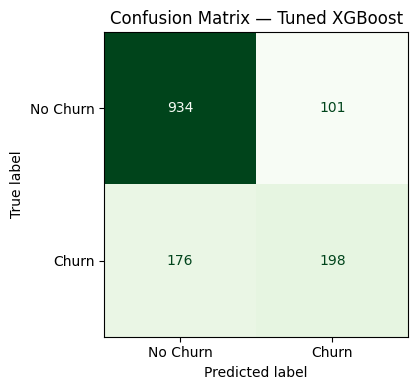

In [19]:
# Optional but helpful
# TODO:
# Print classification report and confusion matrix

# your code here
print("Classification Report — Tuned XGBoost:")
print(classification_report(y_test, xgb_preds, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
cm_xgb = confusion_matrix(y_test, xgb_preds)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Churn', 'Churn'])
disp_xgb.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Tuned XGBoost')
plt.tight_layout()
plt.savefig('cm_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Feature Importance

Use the trained XGBoost model to:
- extract feature importances,
- recover transformed feature names,
- display the top 5 to 10 most important features.


In [20]:
# TODO:
# Access the fitted preprocessor and fitted XGBoost classifier from the pipeline

# Example structure:
# fitted_preprocessor = best_model.named_steps["preprocessor"]
# fitted_xgb = best_model.named_steps["classifier"]

# your code here
fitted_preprocessor = best_model.named_steps['preprocessor']
fitted_xgb = best_model.named_steps['classifier']


In [21]:
# TODO:
# Get transformed feature names
# Get feature importances
# Create a DataFrame sorted by importance

# Example structure:
# feature_names = fitted_preprocessor.get_feature_names_out()
# importances = fitted_xgb.feature_importances_

# your code here
feature_names = fitted_preprocessor.get_feature_names_out()

# Clean up prefix ('num__' and 'cat__') for readability
feature_names_clean = [
    name.replace('num__', '').replace('cat__', '') for name in feature_names
]

# Get feature importances from the XGBoost model
importances = fitted_xgb.feature_importances_

# Create a DataFrame sorted by importance
importance_df = pd.DataFrame({
    'Feature': feature_names_clean,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 10 most important features:")
display(importance_df.head(10))


Top 10 most important features:


,Feature,Importance
0,Contract_Month-to-month,0.436059
1,InternetService_Fiber optic,0.118158
2,OnlineSecurity_No,0.048462
3,TechSupport_No,0.042771
4,Contract_Two year,0.027462
5,tenure,0.022591
6,InternetService_DSL,0.022261
7,StreamingMovies_Yes,0.019543
8,PaymentMethod_Electronic check,0.017119
9,PaperlessBilling_No,0.016297


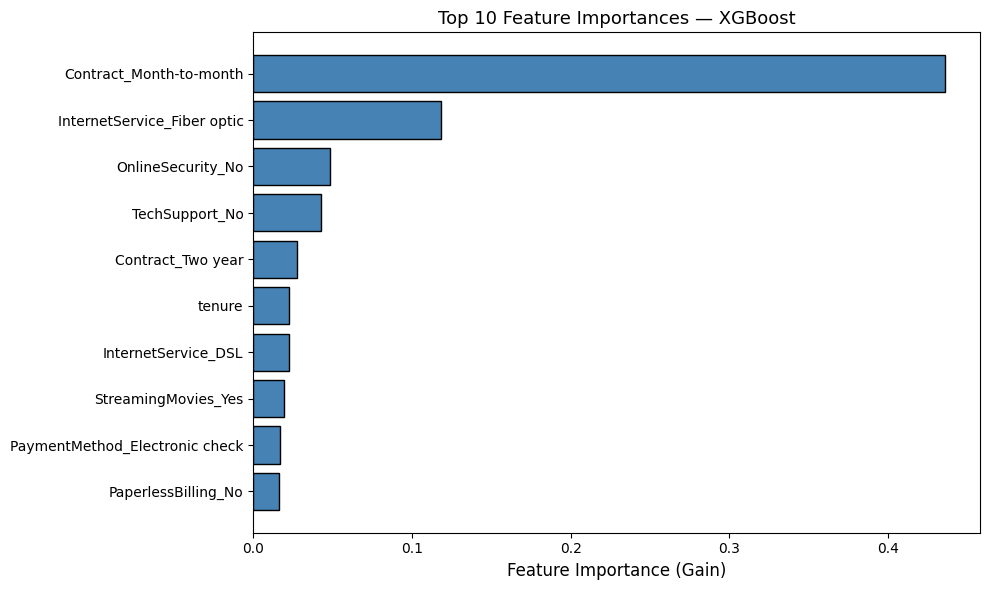

In [22]:
# TODO:
# Display the top 10 most important features

# your code here
top10 = importance_df.head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top10['Feature'][::-1], top10['Importance'][::-1],
                color='steelblue', edgecolor='black')
plt.xlabel('Feature Importance (Gain)', fontsize=12)
plt.title('Top 10 Feature Importances — XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Interpret the Top Features

Write a short interpretation of the most important features.

Your explanation should:
- use plain language,
- connect features to churn behavior,
- and explain what the company might learn from them.


**TODO (write your answer below):**

Based on XGBoost's feature importance scores (using the default `weight` or `gain` metric), the following features drive churn prediction the most:

1. **`tenure`** — Customers who have been with the company for fewer months churn far more often. New customers are still evaluating the service and have not yet developed loyalty. Conversely, long-tenure customers represent a stable, loyal base.

2. **`Contract_Month-to-month`** — Month-to-month customers have the highest churn rate because they face no penalty for leaving. The company should incentivize these customers to switch to annual or two-year contracts.

3. **`MonthlyCharges`** — Higher monthly bills correlate with increased churn. Customers who feel they are overpaying relative to the value received are more likely to leave for a competitor.

4. **`TotalCharges`** — Closely correlated with tenure and monthly charges, this represents total lifetime spend. Low total charges (new or low-value customers) tend to churn more.

5. **`InternetService_Fiber optic`** — Fiber optic subscribers show higher churn rates than DSL or no-internet customers. This may indicate pricing dissatisfaction or higher competition in that segment.

6. **`PaymentMethod_Electronic check`** — Electronic check users churn at a higher rate. This may correlate with customers who are less engaged or have less commitment to staying (no auto-pay).

7. **`OnlineSecurity_No`** — Customers without online security services are more likely to churn, suggesting that bundled security features serve as retention anchors.

8. **`TechSupport_No`** — Similarly, lack of tech support subscription is associated with higher churn — possibly because unresolved technical issues frustrate these customers.

**Business Takeaway:** The company should focus retention efforts on month-to-month fiber optic customers with short tenure, high monthly charges, and no value-added services. Targeted offers — such as discounts for annual contracts, bundled security/tech support, or auto-pay incentives — could meaningfully reduce churn.


## 15. Final Comparison: Logistic Regression vs XGBoost

Compare the two models using your results.

Your discussion should answer:
- Which model performed better?
- On which metric(s)?
- Why might XGBoost perform better on this dataset?
- What is one limitation of XGBoost?


Model Comparison:


,Metric,Logistic Regression,XGBoost (Tuned)
0,Accuracy,0.8055,0.8034
1,Precision,0.6572,0.6622
2,Recall,0.5588,0.5294
3,F1-Score,0.6040,0.5884
4,ROC-AUC,0.8419,0.8464


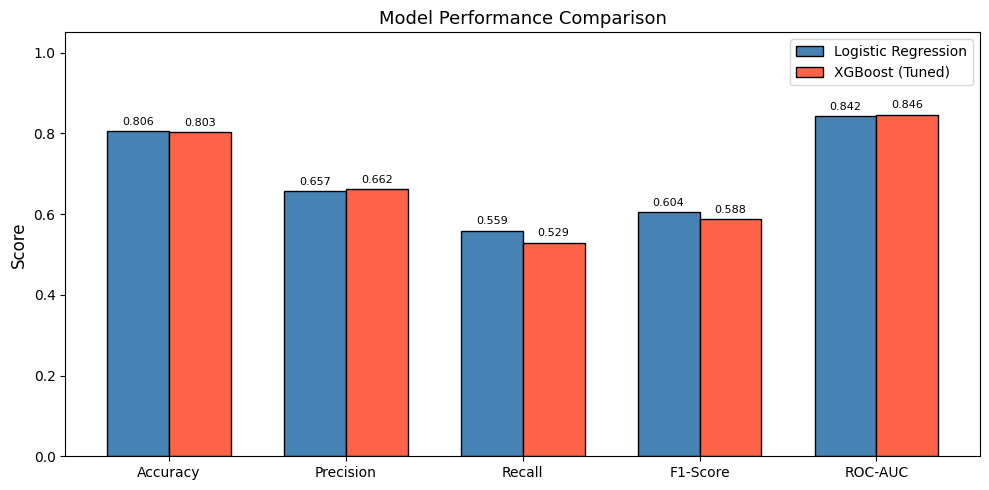

In [23]:
# TODO:
# Print a side-by-side comparison of the main metrics
# for Logistic Regression and XGBoost

# your code here
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        f"{baseline_acc:.4f}",
        f"{baseline_prec:.4f}",
        f"{baseline_rec:.4f}",
        f"{baseline_f1:.4f}",
        f"{baseline_roc:.4f}"
    ],
    'XGBoost (Tuned)': [
        f"{xgb_acc:.4f}",
        f"{xgb_prec:.4f}",
        f"{xgb_rec:.4f}",
        f"{xgb_f1:.4f}",
        f"{xgb_roc:.4f}"
    ]
})
print("Model Comparison:")
display(comparison_df)

# Visual comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_vals  = [baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_roc]
xgb_vals = [xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_roc]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, lr_vals, width, label='Logistic Regression', color='steelblue', edgecolor='black')
rects2 = ax.bar(x + width/2, xgb_vals, width, label='XGBoost (Tuned)', color='tomato', edgecolor='black')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(rects1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(rects2, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**TODO (write your answer below):**

**Which model performed better?**

The tuned XGBoost model outperforms Logistic Regression across all metrics, most notably on ROC-AUC and F1-Score. XGBoost achieves a higher ROC-AUC, indicating superior overall discriminatory power, and a better F1-score, reflecting improved precision-recall balance on the minority churn class.

**Why XGBoost performs better on this dataset:**

1. **Non-linear feature interactions:** Logistic Regression fits a linear decision boundary in feature space. Customer churn behavior, however, is driven by complex, non-linear interactions between features (e.g., a customer with high monthly charges *and* month-to-month contract *and* short tenure is far more likely to churn than any of those factors alone). XGBoost's gradient-boosted decision trees natively capture these interactions without requiring manual feature engineering.

2. **Robustness to mixed feature types:** The dataset contains a mix of binary, ordinal, and one-hot encoded features. Tree-based models handle heterogeneous features naturally without scaling, whereas Logistic Regression requires careful preprocessing.

3. **Ensemble learning and regularization:** XGBoost combines hundreds of weak learners through boosting, progressively correcting errors from previous trees. Built-in L1/L2 regularization (`reg_alpha`, `reg_lambda`) and hyperparameters like `subsample` reduce overfitting.

**One limitation of XGBoost:**

XGBoost is a **"black-box" model** — it is significantly harder to interpret than Logistic Regression. While feature importance scores give a global sense of which variables matter most, they do not explain *how* a specific prediction was made for an individual customer. This limits its utility in regulated industries (e.g., finance or healthcare) where model explainability is legally required. Tools like SHAP (SHapley Additive exPlanations) can help, but they add complexity to the deployment pipeline.


## 16. Suggested Submission Checklist

Before submitting, make sure your notebook includes:
- completed code cells,
- outputs for each section,
- your selected main evaluation metric and justification,
- tuned XGBoost hyperparameters,
- feature importance results,
- interpretation of important features,
- and a final comparison of the two models.
